In [ ]:
import warnings
import glob
import os
import numpy as np
import matplotlib.cm as cm
import matplotlib.pyplot as plt
from tqdm import tqdm


from biophysical_model.dopamine_toolbox import initialize_config_drugs
from utils.model_fitting import slope_log,fit_sigmoid
from utils.plots import *
from utils.path import PathConfig,FigureWithData
from utils.data  import *

warnings.filterwarnings("ignore")
rseed =10
np.random.seed(rseed)



fig_dir = os.path.join('figures', 'figure_8')
data_fig_dir = os.path.join('data', 'source_data', 'figure_8')
os.makedirs(fig_dir, exist_ok=True)
os.makedirs(data_fig_dir, exist_ok=True)




- `res['da']`       : DA concentrarion (Size: N Drug, N DA, N efficacy D2l, N efficacy D2s,N Timestamps)
- `res['d1_occ']`   : D1 occupancy (Size: N Drug, N DA, N efficacy D2l, N efficacy D2s,N Timestamps)
- `res['d2l_occ']`  : D2l occupancy(Size: N Drug, N DA, N efficacy D2l, N efficacy D2s,N Timestamps, N agonists)
- `res['d2s_occ']`  : D2s occupancy(Size: N Drug, N DA, N efficacy D2l, N efficacy D2s,N Timestamps, N agonists)
- `res['d1_act']`   : D1 activation (Size: N Drug, N DA, N efficacy D2l, N efficacy D2s,N Timestamps)
- `res['d2l_act']`  : D2l activation (Size: N Drug, N DA, N efficacy D2l, N efficacy D2s,N Timestamps, N agonists)
- `res['d2s_act']`  :  D2s activation (Size: N Drug, N DA, N efficacy D2l, N efficacy D2s,N Timestamps, N agonists)

Where: 
- N Drug:  number of drug concentrations tested 
- N DA : number of dopamine baseline levels (derived from baseline firing rates from single neurons)
- N efficacy D2l: number of D2l receptor efficacies 
- N efficacy D2s: number of D2s receptor efficacies 
- N Timestamps : NUmber of timestamps per trial 

## Reproduction of drug manipulations

- This code plots the results from the biophysical simulations performed by adding an additional D2 receptor agonist (bromocriptine)
- The simulations were done to reproduce the effects of bromocriptine on reversal learning in the study from Cools et al, 2009 in which healthy humans were given this drug and asked to perform a reversal task
- The files of the simnulations are dictionaries, containing:
    - `res['da']`       : DA concentrarion (Size: N Drug, N DA, N efficacy D2l, N efficacy D2s,N Timestamps)
    - `res['d1_occ']`   : D1 occupancy (Size: N Drug, N DA, N efficacy D2l, N efficacy D2s,N Timestamps)
    - `res['d2l_occ']`  : D2l occupancy(Size: N Drug, N DA, N efficacy D2l, N efficacy D2s,N Timestamps, N agonists)
    - `res['d2s_occ']`  : D2s occupancy(Size: N Drug, N DA, N efficacy D2l, N efficacy D2s,N Timestamps, N agonists)
    - `res['d1_act']`   : D1 activation (Size: N Drug, N DA, N efficacy D2l, N efficacy D2s,N Timestamps)
    - `res['d2l_act']`  : D2l activation (Size: N Drug, N DA, N efficacy D2l, N efficacy D2s,N Timestamps, N agonists)
    - `res['d2s_act']`  :  D2s activation (Size: N Drug, N DA, N efficacy D2l, N efficacy D2s,N Timestamps, N agonists)

    Where: 
    - N Drug:  number of drug concentrations tested 
    - N DA : number of dopamine baseline levels (derived from inducing shifts in the baseline firing rates of single neurons)
    - N efficacy D2l: number of D2l receptor efficacies 
    - N efficacy D2s: number of D2s receptor efficacies 
    - N Timestamps : NUmber of timestamps per trial 


In [2]:
#%% Load single unit simulations
paths = PathConfig()
g_dir = paths.g2_dir
data_path = os.path.join(g_dir,'drug_experiments')
file_list = glob.glob(data_path + '/*_results_only_base.npy')
res_mats = []
for id_unit in tqdm(range(len(file_list))):
    print([file_list[id_unit],id_unit])
    res_mats.append(np.load(file_list[id_unit],allow_pickle=True).item())
drug_concv, efficacies, ndrug, neffs, id_bins_base,da_base,rec_base,log_delta,ec50_d1,ec50_d2,da_eta = initialize_config_drugs()
nunits = len(res_mats)
nda = res_mats[0]['da'].shape[1]
nda_base =len(da_base)
n_points = len(da_eta)
efficacies_p = np.ceil(efficacies*10)/10

  0%|          | 0/40 [00:00<?, ?it/s]

['data/googledrive/drug_experiments/r_HeA_2013-03-23_15-18-34_TT7_1_results_only_base.npy', 0]


  5%|▌         | 2/40 [00:00<00:07,  5.01it/s]

['data/googledrive/drug_experiments/r_HeJ_2013-06-19_13-51-02_TT1_1_results_only_base.npy', 1]
['data/googledrive/drug_experiments/r_HeA_2013-03-22_15-38-57_TT8_1_results_only_base.npy', 2]


 10%|█         | 4/40 [00:00<00:07,  5.12it/s]

...

 95%|█████████▌| 38/40 [00:13<00:01,  1.11it/s]

['data/googledrive/drug_experiments/r_HeA_2013-03-18_18-34-09_TT7_2_results_only_base.npy', 38]


 98%|█████████▊| 39/40 [00:14<00:00,  1.04it/s]

['data/googledrive/drug_experiments/r_K_2012-07-27_14-47-25_TT4_2_results_only_base.npy', 39]


100%|██████████| 40/40 [00:15<00:00,  2.67it/s]


### Dose-occupancy curve in the presence of bromocriptine
The following code fits a sigmoid function to compute the dose-occupancy curves of the D2 recptors in the presence of difference concentrations (color) and efficacies of the dopamine agonist bromocriptine 

In [3]:
#%% Fit sigmoid to the curves for d2 activation: 
ec50_act, bias_act = np.zeros((neffs,neffs,ndrug)), np.zeros((neffs,neffs,ndrug))
ec50_occ, bias_occ = np.zeros((neffs,neffs,ndrug)), np.zeros((neffs,neffs,ndrug))
popts_occ,popts_act = np.zeros((neffs,neffs,ndrug,4)), np.zeros((neffs,neffs,ndrug,4))
mus_da,mus_occ,mus_act =  np.zeros((neffs,neffs,ndrug,nda)),np.zeros((neffs,neffs,ndrug,nda)),np.zeros((neffs,neffs,ndrug,nda))
yfits_occ,yfits_act =  np.zeros((neffs,neffs,ndrug,nda_base)),np.zeros((neffs,neffs,ndrug,nda_base))

for i_eff_d2l in range(neffs):
    for i_eff_d2s in range(neffs):
        for idr,drug_conc in zip(range(ndrug),drug_concv):
            temp_act,temp_occ,temp_da = np.nan*np.ones((nda,nunits)),np.nan*np.ones((nda,nunits)),np.nan*np.ones((nda,nunits))
            for id_unit in range(nunits):
                temp_da[:,id_unit] = np.nanmean(res_mats[id_unit]['da'][0,:,i_eff_d2l,i_eff_d2s,id_bins_base],axis=0)
                temp_act[:,id_unit] = np.nanmean( res_mats[id_unit]['d2l_act'][idr,:,i_eff_d2l,i_eff_d2s,id_bins_base],axis=0)
                temp_occ[:,id_unit] = np.nanmean(np.sum(res_mats[id_unit]['d2l_occ'][idr,:,i_eff_d2l,i_eff_d2s,id_bins_base],axis=2),axis=0)   
            mu_act,mu_occ,mu_da = np.nanmean(temp_act,axis=1) ,np.nanmean(temp_occ,axis=1) ,np.nanmean(temp_da,axis=1) 
            mus_da[i_eff_d2l,i_eff_d2s,idr,:],mus_occ[i_eff_d2l,i_eff_d2s,idr,:],mus_act[i_eff_d2l,i_eff_d2s,idr,:] = mu_da,mu_occ,mu_act
            popt_occ, _,yfit_occ = fit_sigmoid(mu_da,mu_occ,da_base,log_xscale=True)
            popt_act, _,yfit_act = fit_sigmoid(mu_da,mu_act,da_base,log_xscale=True)
            yfits_occ[i_eff_d2l,i_eff_d2s,idr,:],yfits_act[i_eff_d2l,i_eff_d2s,idr,:] = yfit_occ,yfit_act
            bias_act[i_eff_d2l,i_eff_d2s,idr] = popt_act[-1]
            popts_act[i_eff_d2l,i_eff_d2s,idr,:] = popt_act
            bias_occ[i_eff_d2l,i_eff_d2s,idr] = popt_occ[-1]
            ec50_occ[i_eff_d2l,i_eff_d2s,idr] = popt_occ[1]
            popts_occ[i_eff_d2l,i_eff_d2s,idr,:] = popt_occ


### Figure 7 
Example of of dose-occupancy curves of the D2 recptors in the presence of difference concentrations (color) and efficacies of the dopamine agonist bromocriptine 
Plot in FIgure 7 is a schematic of this data

Saved figure to figures/figure_8/figure_sigmoid_d2l_occ_subset.pdf
Saved data and stats to data/figure_data/figure_8/figure_sigmoid_d2l_occ_subset.txt
Saved figure to figures/figure_8/figure_sigmoid_d2l_act_subset.pdf
Saved data and stats to data/figure_data/figure_8/figure_sigmoid_d2l_act_subset.txt


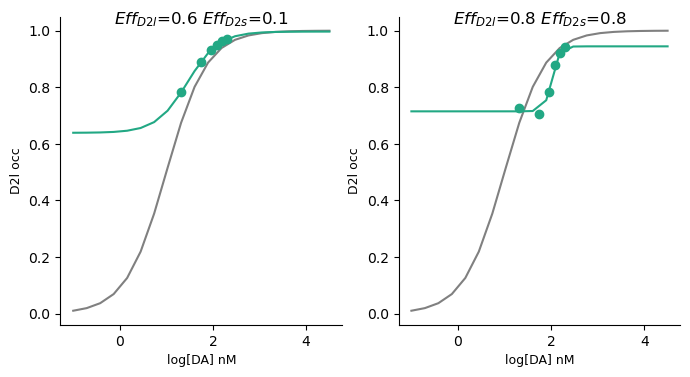

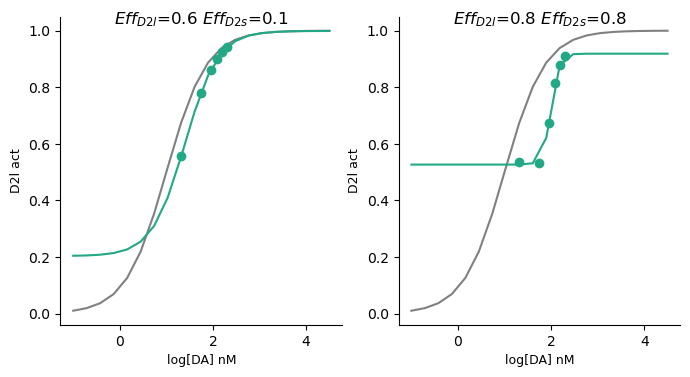

In [4]:
#%% Plot sigmoid to the curves for d2 activation: 

idr = 6
neffs_plot = 2
ieffs_d2l = [3,4]
ieffs_d2s = [0,4]

__,axo = plt.subplots(1,neffs_plot,figsize=(neffs_plot*4,4))
__,axa = plt.subplots(1,neffs_plot,figsize=(neffs_plot*4,4))
drug_conc = drug_concv[idr]

for ((id_eff_d2l,i_eff_d2l),(id_eff_d2s,i_eff_d2s)) in zip(enumerate(ieffs_d2l),enumerate(ieffs_d2s)):
    axo[id_eff_d2s].plot(da_base,rec_base,color='grey')
    axa[id_eff_d2s].plot(da_base,rec_base,color='grey')

    mu_da, mu_occ, mu_act = mus_da[i_eff_d2l,i_eff_d2s,idr,:],mus_occ[i_eff_d2l,i_eff_d2s,idr,:],mus_act[i_eff_d2l,i_eff_d2s,idr,:]
    yfit_occ, yfit_act = yfits_occ[i_eff_d2l,i_eff_d2s,idr,:],yfits_act[i_eff_d2l,i_eff_d2s,idr,:]
    axo[id_eff_d2s].plot(np.log10(mu_da),mu_occ,'o',color=cm.viridis(idr/len(drug_concv)) )
    axo[id_eff_d2s].plot(da_base,yfit_occ,color=cm.viridis(idr/len(drug_concv)) )
    axa[id_eff_d2s].plot(np.log10(mu_da),mu_act,'o',color=cm.viridis(idr/len(drug_concv)) )
    axa[id_eff_d2s].plot(da_base,yfit_act,color=cm.viridis(idr/len(drug_concv)) )
    
    plot_config(axo[id_eff_d2s],'log[DA] nM','D2l occ',9,False)
    plot_config(axa[id_eff_d2s],'log[DA] nM','D2l act',9,False)
    axo[id_eff_d2s].set_title(r'$Eff_{D2l}$='+str(efficacies_p[i_eff_d2l])+r' $Eff_{D2s}$='+str(efficacies_p[i_eff_d2s]),y=.95)
    axa[id_eff_d2s].set_title(r'$Eff_{D2l}$='+str(efficacies_p[i_eff_d2l])+r' $Eff_{D2s}$='+str(efficacies_p[i_eff_d2s]),y=.95)


# Create FigureWithData instances
fig_data_sigmoid_occ_small = FigureWithData(axo[0].figure)
fig_data_sigmoid_act_small = FigureWithData(axa[0].figure)

# Prepare and add data
for fig_data, data_array, label in [
    (fig_data_sigmoid_occ_small, mus_occ, "D2l_Occupancy"),
    (fig_data_sigmoid_act_small, mus_act, "D2l_Activation")
]:
    combined_data = []
    for i_eff_d2l, i_eff_d2s in zip(ieffs_d2l, ieffs_d2s):
        mu_da = mus_da[i_eff_d2l, i_eff_d2s, idr, :]
        mu_response = data_array[i_eff_d2l, i_eff_d2s, idr, :]
        valid_idx = np.isfinite(mu_da) & np.isfinite(mu_response)
        eff_d2l_val = efficacies_p[i_eff_d2l]
        eff_d2s_val = efficacies_p[i_eff_d2s]
        meta_col = np.full((np.sum(valid_idx), 2), [eff_d2l_val, eff_d2s_val])
        data = np.column_stack((meta_col, np.log10(mu_da[valid_idx]), mu_response[valid_idx]))
        combined_data.append(data)
    combined_data = np.vstack(combined_data)
    headers = ['Eff_D2l', 'Eff_D2s', 'log_DA_nM', label]
    fig_data.add_data(f"Sigmoid D2l {label} (subset)", combined_data, headers)

# Save figures and data
fig_data_sigmoid_occ_small.save(
    base_filename='figure_sigmoid_d2l_occ_subset',
    folder_data=data_fig_dir,
    folder_figures=fig_dir,
)

fig_data_sigmoid_act_small.save(
    base_filename='figure_sigmoid_d2l_act_subset',
    folder_data=data_fig_dir,
    folder_figures=fig_dir,
)

### Receptor sensitivities and asymmetric scaling factor in the presence of bromocriptine
The following code computes:
- Receptor sensitivities of D1 and D2 receptors (slopes of the dose-occupancy curve given a `log_delta` transient in dopamine )
- Asymmetric scaling factor $\tau$ given by the receptor sensitivities

The parameters were computed in the presence of difference concentrations and efficacies of the dopamine agonist bromocriptine , as well as for different levels of baseline dopamine concentration

In [5]:

d1_slope = np.zeros((neffs,neffs,ndrug+1,n_points))
d2_slope_act = np.zeros((neffs,neffs,ndrug+1,n_points))
eta_act = np.zeros((neffs,neffs,ndrug+1,n_points))
d2_slope_occ = np.zeros((neffs,neffs,ndrug+1,n_points))
eta_occ = np.zeros((neffs,neffs,ndrug+1,n_points))
for i_eff_d2l in range(neffs):
    for i_eff_d2s in range(neffs):
        for idr,idrug in enumerate(np.arange(-1,ndrug)):
            d1temp,d2temp_act,d2temp_occ =np.zeros(n_points),np.zeros(n_points),np.zeros(n_points)
            for id  in np.arange(n_points):
                if idrug>-1:
                    popt_act = popts_act[i_eff_d2l,i_eff_d2s,idrug,:]
                    popt_occ = popts_occ[i_eff_d2l,i_eff_d2s,idrug,:]
                    d2_slope_act[i_eff_d2l,i_eff_d2s,idr,id] = slope_log(da_eta[id],log_delta,popt_act,type_sigm ='full')
                    d2_slope_occ[i_eff_d2l,i_eff_d2s,idr,id] = slope_log(da_eta[id],log_delta,popt_occ,type_sigm ='full')
                else:
                    d2_slope_act[i_eff_d2l,i_eff_d2s,idr,id]  = slope_log(10**da_eta[id],1/2,ec50_d2,type_sigm ='simple')
                    d2_slope_occ[i_eff_d2l,i_eff_d2s,idr,id]  = slope_log(10**da_eta[id],1/2,ec50_d2,type_sigm ='simple')
                d1_slope[i_eff_d2l,i_eff_d2s,idr,id] = slope_log(10**da_eta[id],3,ec50_d1,type_sigm ='simple')
            eta_act[i_eff_d2l,i_eff_d2s,idr,:] = np.divide(d1_slope[i_eff_d2l,i_eff_d2s,idr,:],(d1_slope[i_eff_d2l,i_eff_d2s,idr,:]+d2_slope_act[i_eff_d2l,i_eff_d2s,idr,:]))
            eta_occ[i_eff_d2l,i_eff_d2s,idr,:] = np.divide(d1_slope[i_eff_d2l,i_eff_d2s,idr,:],(d1_slope[i_eff_d2l,i_eff_d2s,idr,:]+d2_slope_occ[i_eff_d2l,i_eff_d2s,idr,:]))

        drug_concp = np.concatenate([np.asarray([0]),drug_concv])

### Figure 7 

Plots of the change in the relative reversal learning parameter ( 2 $\tau$ -1) reported by Cools et al, 2009

Saved figure to figures/figure_8/figure_diff_tau_occ_subset.pdf
Saved data and stats to data/figure_data/figure_8/figure_diff_tau_occ_subset.txt
Saved figure to figures/figure_8/figure_diff_tau_act_subset.pdf
Saved data and stats to data/figure_data/figure_8/figure_diff_tau_act_subset.txt


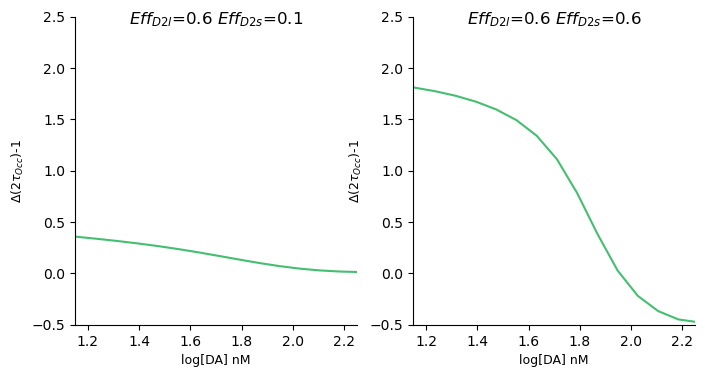

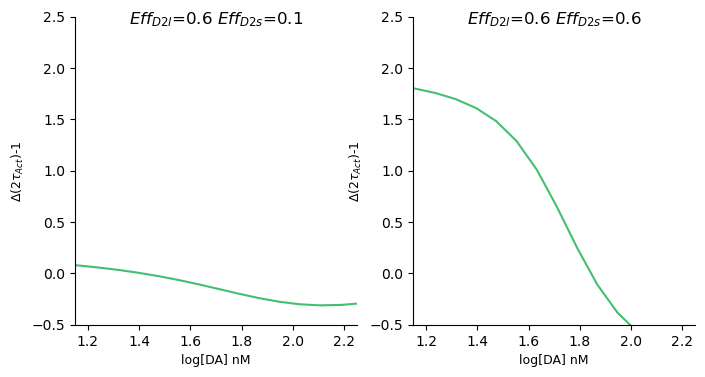

In [13]:
# #%% Plot sigmoid to the curves for d2 activation: 

neffs_plot = 2
ieff=3
idrug = 7
ieffs_d2l = [ieff,ieff]
ieffs_d2s = [0,ieff]

# Plot change in asymmetric scaling factors per efficiency:
figo,axo = plt.subplots(1,neffs_plot,figsize=(neffs_plot*4,4))
figa,axa = plt.subplots(1,neffs_plot,figsize=(neffs_plot*4,4))
drug_conc = drug_concv[idrug]

for ((id_eff_d2l,i_eff_d2l),(id_eff_d2s,i_eff_d2s)) in zip(enumerate(ieffs_d2l),enumerate(ieffs_d2s)):

    diff_o = (2*eta_occ[i_eff_d2l,i_eff_d2s,idrug,:]-1)-(2*eta_occ[i_eff_d2l,i_eff_d2s,0,:]-1)
    diff_a = (2*eta_act[i_eff_d2l,i_eff_d2s,idrug,:]-1)-(2*eta_act[i_eff_d2l,i_eff_d2s,0,:]-1)

    axo[id_eff_d2l].plot(da_eta,diff_o,color=cm.viridis(idrug/ndrug),
        label=str(np.ceil(drug_concp[idrug]*100)/100)+ ' nM')
    axa[id_eff_d2s].plot(da_eta,diff_a,color=cm.viridis(idrug/ndrug),
        label=str(np.ceil(drug_concp[idrug]*100)/100)+ ' nM')
    axo[id_eff_d2l].set_title(r'$Eff_{D2l}$='+str(efficacies_p[i_eff_d2l])+r' $Eff_{D2s}$='+str(efficacies_p[i_eff_d2s]),y=.95)
    axa[id_eff_d2s].set_title(r'$Eff_{D2l}$='+str(efficacies_p[i_eff_d2l])+r' $Eff_{D2s}$='+str(efficacies_p[i_eff_d2s]),y=.95)
_=[plot_config(ia,'log[DA] nM',r'$\Delta$(2$\tau_{Occ}$)-1',9,False) for ia in axo.flatten()]
_=[plot_config(ia,'log[DA] nM',r'$\Delta$(2$\tau_{Act}$)-1',9,False) for ia in axa.flatten()]  
_=[ia.set_xlim(1.15,2.25) for ia in axa.flatten()]
_=[ia.set_xlim(1.15,2.25) for ia in axo.flatten()]
_=[ia.set_ylim(-.5,2.5) for ia in axa.flatten()]
_=[ia.set_ylim(-.5,2.5) for ia in axo.flatten()]

# --- Save asymmetric scaling factor *differences* using FigureWithData ---

fig_data_diff_occ = FigureWithData(figo)
fig_data_diff_act = FigureWithData(figa)

# Prepare and add data
for fig_data, data_array, label in [
    (fig_data_diff_occ, eta_occ, "Delta_Tau_Occ"),
    (fig_data_diff_act, eta_act, "Delta_Tau_Act")
]:
    combined_data = []
    for i_eff_d2l, i_eff_d2s in zip(ieffs_d2l, ieffs_d2s):
        diff = (2 * data_array[i_eff_d2l, i_eff_d2s, idrug, :] - 1) - (2 * data_array[i_eff_d2l, i_eff_d2s, 0, :] - 1)
        valid_idx = np.isfinite(diff)
        eff_d2l_val = efficacies_p[i_eff_d2l]
        eff_d2s_val = efficacies_p[i_eff_d2s]
        meta_col = np.full((np.sum(valid_idx), 2), [eff_d2l_val, eff_d2s_val])
        data = np.column_stack((meta_col, da_eta[valid_idx], diff[valid_idx]))
        combined_data.append(data)
    combined_data = np.vstack(combined_data)
    headers = ['Eff_D2l', 'Eff_D2s', 'log_DA_nM', label]
    fig_data.add_data(f"Asymmetric Scaling Changes ({label})", combined_data, headers)

# Save figures and data
fig_data_diff_occ.save(
    base_filename='figure_diff_tau_occ_subset',
    folder_data=data_fig_dir,
    folder_figures=fig_dir,
)

fig_data_diff_act.save(
    base_filename='figure_diff_tau_act_subset',
    folder_data=data_fig_dir,
    folder_figures=fig_dir,
)




In [14]:
import pandas as pd 
# Model task 
#  The maximum number of reversal stages per block was 14, although the block terminated automatically after completion of 120 trials (∼6.6 min). 
# Learning criteria (i.e. the number of consecutive correct trials following which the contingencies changed) varied between stages
# (but not between conditions or subjects, see below) according to a pre-set fixed pseudorandom sequence (mean = 6.9; S.D. = 1.8; range from 5 to 9), 
# in order to prevent predictability of reversals.

# Model one block: 
rew_pun = [[1,-1],[-1,1]]
id_pairing = 0
id_pairings = np.arange(len(rew_pun))
n_trials_practice = 50
n_trials_max_block =500
n_trials_max = n_trials_max_block+n_trials_practice
n_blocks = 20
trials_correct = np.arange(5,10)
p_trials_correct = [.1,.2,.4,.2,.1]
n_samples =1
n_stimuli = 2
alpha = .1
tau = .1
acc_rewpun = []
thrs_rpe = 1.5
acc_rew_pun = {'accuracy_rew_rev':[],'accuracy_pun_rev':[],'rel_rewpun':[],'drug_conc':[],'eff_d2l':[],'eff_d2s':[],
               'eta':[],'eta_type':[],'da_conc':[],'i_block':[]}
eta_types = ['occ','act']
etas_v = [eta_occ,eta_act]
for (ie,eta_type) in enumerate(eta_types):
    print('******* Eta type:' + eta_type+'*******')
    etas = etas_v[ie]
    for i_eff_d2l in range(neffs):
        print('*******Efficacy :' + str(efficacies[i_eff_d2l])+'*******')
        for i_eff_d2s in range(neffs):
            for idrug in np.arange(ndrug+1):
                for ida in np.arange(nda_base):
                    ieta = etas[i_eff_d2l,i_eff_d2s,idrug,ida]
                    da_conc = da_eta[ida]
                    
                    for ib in range(n_blocks):
                        vi = np.zeros(2)
                        val_stim, id_trials_rev = [],[]
                        n_trials_correct = trials_correct[np.random.choice(len(trials_correct), n_samples, p=p_trials_correct)]
                        correct_count = 0
                        n_tr_rev =0
                        
                        for itr in (range(n_trials_max)):
                            if n_tr_rev==1 and  itr>n_trials_practice:
                                i_stim = i_stim
                            else:
                                i_stim = np.random.choice(n_stimuli, n_samples, p=[.5,.5])[0]
                            rew = rew_pun[id_pairing][i_stim]        
                            rpe = rew - vi[i_stim]
                            if rpe>=0:
                                lr = alpha*ieta
                            else:
                                lr = alpha*(1-ieta)
                            
                            vi[i_stim] += lr*rpe
                            corr_i = (vi[i_stim]*rpe>=0)*(np.abs(rpe)<=thrs_rpe)
                            val_stim.append([vi[i_stim], i_stim,id_pairing,corr_i,rew])
                            if itr>n_trials_practice:
                                n_tr_rev+=1
                                if corr_i:
                                    correct_count+=1
                                if correct_count>n_trials_correct:
                                    id_pairing = id_pairings[id_pairings!=id_pairing][0]
                                    correct_count = 0
                                    n_tr_rev = 0 
                                    id_trials_rev.append(itr+1)
                                

                        val_stim = np.array(val_stim)
                        id_trials_rev = np.array(id_trials_rev)
                        id_trials_rev = id_trials_rev[id_trials_rev<val_stim.shape[0]-1]
                        acc_rev = val_stim[id_trials_rev+1,3]
                        rew_rev = val_stim[id_trials_rev+1,4]

                        acc_rew_pun['accuracy_rew_rev'].append(np.sum(acc_rev[rew_rev>0])/np.sum(rew_rev>0))
                        acc_rew_pun['accuracy_pun_rev'].append(np.sum(acc_rev[rew_rev<0])/np.sum(rew_rev<0))
                        acc_rew_pun['rel_rewpun'].append(np.sum(acc_rev[rew_rev>0])/np.sum(rew_rev>0)-np.sum(acc_rev[rew_rev<0])/np.sum(rew_rev<0))
                        acc_rew_pun['drug_conc'].append(drug_concp[idrug])
                        acc_rew_pun['eff_d2l'].append(efficacies[i_eff_d2l])
                        acc_rew_pun['eff_d2s'].append(efficacies[i_eff_d2s])                               
                        acc_rew_pun['eta'].append(ieta)
                        acc_rew_pun['eta_type'].append(eta_type)
                        acc_rew_pun['da_conc'].append(da_conc)
                        acc_rew_pun['i_block'].append(ib)
da = pd.DataFrame(acc_rew_pun)

******* Eta type:occ*******
*******Efficacy :0.1*******
*******Efficacy :0.26*******
*******Efficacy :0.42000000000000004*******
*******Efficacy :0.58*******
*******Efficacy :0.74*******
*******Efficacy :0.9*******
******* Eta type:act*******
*******Efficacy :0.1*******
*******Efficacy :0.26*******
*******Efficacy :0.42000000000000004*******
*******Efficacy :0.58*******
*******Efficacy :0.74*******
*******Efficacy :0.9*******


Saved figure to figures/figure_8/figure_rrl_no_drug.pdf
Saved data and stats to data/figure_data/figure_8/figure_rrl_no_drug.txt


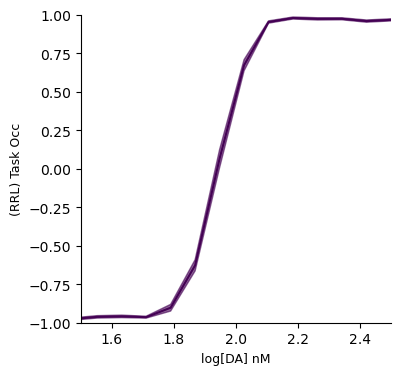

In [15]:
# Plot  RRL in absence of drug 
drug_str =np.concatenate([['0'],[str(ii) for ii in np.round(drug_concv,2)]])
idrug = 0
figo,axo = plt.subplots(1,1,figsize=(1*4,1*4))
i_eff_d2l = 0

d_=filter_pd(da,['drug_conc','eff_d2l','eff_d2s','eta_type'],
            [drug_concp[idrug],efficacies[i_eff_d2l],efficacies[i_eff_d2s],'occ'],
            ['equal','equal','equal','equal'])
rel_rewpun = np.array(d_['rel_rewpun'].to_list())
da_conc = np.array(d_['da_conc'].to_list())
mu_per_da_occ = np.array([np.nanmean(rel_rewpun[da_conc==ida]) for ida in np.unique(da_conc)])
sem_per_da_occ = np.array([np.nanstd(rel_rewpun[da_conc==ida])/np.sqrt(len(rel_rewpun[da_conc==ida])) for ida in np.unique(da_conc)])

axo.plot(da_eta,mu_per_da_occ,color=cm.viridis(idrug/ndrug),
    label=str(np.ceil(drug_concp[idrug]*100)/100)+ ' nM')
axo.fill_between(da_eta,
                                        mu_per_da_occ+sem_per_da_occ,
                                        mu_per_da_occ-sem_per_da_occ,
                                        color=cm.viridis(idrug/ndrug),alpha=.6,
                                        label=str(np.ceil(drug_concp[idrug]*100)/100)+ ' nM')

plot_config(axo,'log[DA] nM',r'(RRL) Task Occ',9,False) 
axo.set_ylim([-1,1]) 
axo.set_xlim([1.5,2.5]) 

# --- Save RRL in absence of drug using FigureWithData ---

fig_data_rrl = FigureWithData(figo)

# Prepare data
valid_idx = np.isfinite(mu_per_da_occ)
data_rrl = np.column_stack((da_eta[valid_idx], mu_per_da_occ[valid_idx], sem_per_da_occ[valid_idx]))
headers_rrl = ['log_DA_nM', 'Mean_RRL', 'SEM_RRL']

# Add to the figure wrapper
fig_data_rrl.add_data("RRL task occupancy (no drug)", data_rrl, headers_rrl)

# Save figure and data
fig_data_rrl.save(
    base_filename='figure_rrl_no_drug',
    folder_data=data_fig_dir,
    folder_figures=fig_dir,
)



Saved figure to figures/figure_8/figure_drl_delta_rrl_occ.pdf
Saved data and stats to data/figure_data/figure_8/figure_drl_delta_rrl_occ.txt
Saved figure to figures/figure_8/figure_drl_delta_rrl_act.pdf
Saved data and stats to data/figure_data/figure_8/figure_drl_delta_rrl_act.txt


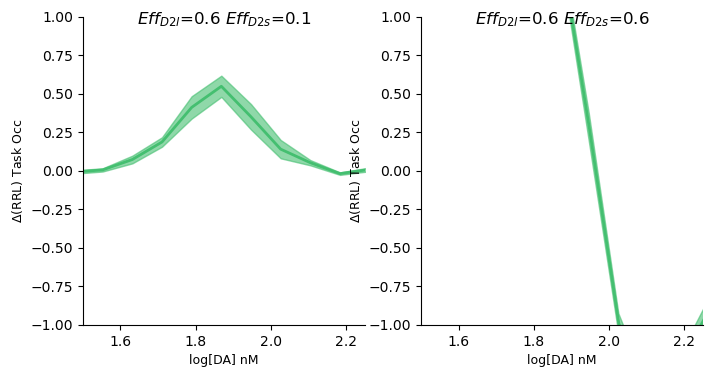

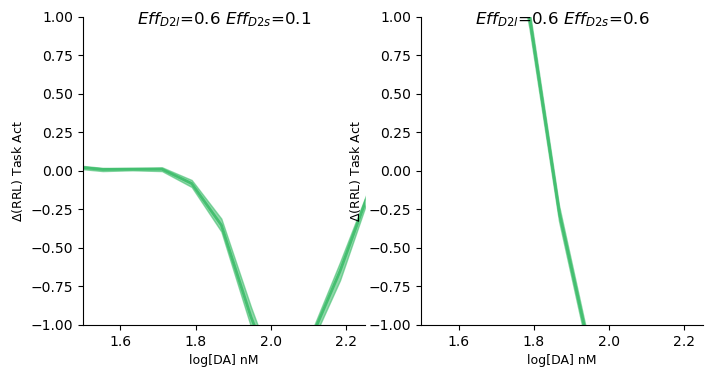

In [21]:
# Plot change in asymmetric scaling factors per efficiency:
drug_str =np.concatenate([['0'],[str(ii) for ii in np.round(drug_concv,2)]])
ieff=3
idrug = 7
ieffs_d2l = [ieff,ieff]
ieffs_d2s = [0,ieff]
neffs_plot= len(ieffs_d2l)


figo,axo = plt.subplots(1,neffs_plot,figsize=(neffs_plot*4,1*4))
figa,axa = plt.subplots(1,neffs_plot,figsize=(neffs_plot*4,1*4))
for ((id_eff_d2l,i_eff_d2l),(id_eff_d2s,i_eff_d2s)) in zip(enumerate(ieffs_d2l),enumerate(ieffs_d2s)):

  
      d_=filter_pd(da,['drug_conc','eff_d2l','eff_d2s','eta_type'],
                  [drug_concp[idrug],efficacies[i_eff_d2l],efficacies[i_eff_d2s],'occ'],
                  ['equal','equal','equal','equal'])
      rel_rewpun = np.array(d_['rel_rewpun'].to_list())
      da_conc = np.array(d_['da_conc'].to_list())
      mu_per_da_occ = np.array([np.nanmean(rel_rewpun[da_conc==ida]) for ida in np.unique(da_conc)])

      d0_=filter_pd(da,['drug_conc','eff_d2l','eff_d2s','eta_type'],
                  [drug_concp[0],efficacies[i_eff_d2l],efficacies[i_eff_d2s],'occ'],
                  ['equal','equal','equal','equal'])
      rel_rewpun_0 = np.array(d0_['rel_rewpun'].to_list())
      da_conc_0 = np.array(d0_['da_conc'].to_list())

      diff_o = np.array([np.nanmean(rel_rewpun[da_conc==ida]-rel_rewpun_0[da_conc_0==ida]) for ida in np.unique(da_conc)])
      diff_std_o = np.array([np.nanstd(rel_rewpun[da_conc==ida]-rel_rewpun_0[da_conc_0==ida])/np.sqrt(len(rel_rewpun[da_conc==ida])) for ida in np.unique(da_conc)])
      d_=filter_pd(da,['drug_conc','eff_d2l','eff_d2s','eta_type'],
                  [drug_concp[idrug],efficacies[i_eff_d2l],efficacies[i_eff_d2s],'act'],
                  ['equal','equal','equal','equal'])
      rel_rewpun = np.array(d_['rel_rewpun'].to_list())
      da_conc = np.array(d_['da_conc'].to_list())
      mu_per_da_act = np.array([np.nanmean(rel_rewpun[da_conc==ida]) for ida in np.unique(da_conc)])

      d0_=filter_pd(da,['drug_conc','eff_d2l','eff_d2s','eta_type'],
                  [drug_concp[0],efficacies[i_eff_d2l],efficacies[i_eff_d2s],'act'],
                  ['equal','equal','equal','equal'])
      rel_rewpun_0 = np.array(d0_['rel_rewpun'].to_list())
      da_conc_0 = np.array(d0_['da_conc'].to_list())

      diff_a = np.array([np.nanmean(rel_rewpun[da_conc==ida]-rel_rewpun_0[da_conc_0==ida]) for ida in np.unique(da_conc)])
      diff_std_a = np.array([np.nanstd(rel_rewpun[da_conc==ida]-rel_rewpun_0[da_conc_0==ida])/np.sqrt(len(rel_rewpun[da_conc==ida])) for ida in np.unique(da_conc)])
      axo[id_eff_d2l].plot(da_eta,diff_o,color=cm.viridis(idrug/ndrug),lw=2)
      axo[id_eff_d2l].fill_between(da_eta,
                                            diff_o+diff_std_o,diff_o-diff_std_o,
                                            color=cm.viridis(idrug/ndrug),alpha=.6,
                                              label=str(np.ceil(drug_concp[idrug]*100)/100)+ ' nM')
      axa[id_eff_d2l].plot(da_eta,diff_a,color=cm.viridis(idrug/ndrug),lw=2)
      axa[id_eff_d2l].fill_between(da_eta,
                                            diff_a+diff_std_a,diff_a-diff_std_a,
                                            color=cm.viridis(idrug/ndrug),alpha=.6,
                                              label=str(np.ceil(drug_concp[idrug]*100)/100)+ ' nM')
      axo[id_eff_d2l].set_title(r'$Eff_{D2l}$='+str(efficacies_p[i_eff_d2l])+r' $Eff_{D2s}$='+str(efficacies_p[i_eff_d2s]),y=.95)
      axa[id_eff_d2l].set_title(r'$Eff_{D2l}$='+str(efficacies_p[i_eff_d2l])+r' $Eff_{D2s}$='+str(efficacies_p[i_eff_d2s]),y=.95)

_=[plot_config(ia,'log[DA] nM',r'$\Delta$(RRL) Task Occ',9,False) for ia in axo.flatten()]
_=[plot_config(ia,'log[DA] nM',r'$\Delta$(RRL) Task Act',9,False) for ia in axa.flatten()]  
_=[ia.set_ylim([-1,1]) for ia in   axo.flatten()]
_=[ia.set_ylim([-1,1]) for ia in   axa.flatten()]
_=[ia.set_xlim([1.5,2.25]) for ia in   axo.flatten()]
_=[ia.set_xlim([1.5,2.25]) for ia in   axa.flatten()]


# --- Save change in asymmetric scaling factors figure ---

# Wrap figures
fig_data_diff_occ = FigureWithData(figo)
fig_data_diff_act = FigureWithData(figa)

# Save data per panel
for (id_eff_d2l, i_eff_d2l), (id_eff_d2s, i_eff_d2s) in zip(enumerate(ieffs_d2l), enumerate(ieffs_d2s)):

    # Recompute exactly like plotted
    d_occ = filter_pd(da, ['drug_conc', 'eff_d2l', 'eff_d2s', 'eta_type'],
                      [drug_concp[idrug], efficacies[i_eff_d2l], efficacies[i_eff_d2s], 'occ'],
                      ['equal', 'equal', 'equal', 'equal'])
    rel_rewpun_occ = np.array(d_occ['rel_rewpun'].to_list())
    da_conc_occ = np.array(d_occ['da_conc'].to_list())
    d0_occ = filter_pd(da, ['drug_conc', 'eff_d2l', 'eff_d2s', 'eta_type'],
                       [drug_concp[0], efficacies[i_eff_d2l], efficacies[i_eff_d2s], 'occ'],
                       ['equal', 'equal', 'equal', 'equal'])
    rel_rewpun0_occ = np.array(d0_occ['rel_rewpun'].to_list())
    da_conc0_occ = np.array(d0_occ['da_conc'].to_list())

    diff_occ = np.array([np.nanmean(rel_rewpun_occ[da_conc_occ==ida] - rel_rewpun0_occ[da_conc0_occ==ida])
                         for ida in np.unique(da_conc_occ)])
    diff_std_occ = np.array([np.nanstd(rel_rewpun_occ[da_conc_occ==ida] - rel_rewpun0_occ[da_conc0_occ==ida])/np.sqrt(len(rel_rewpun_occ[da_conc_occ==ida]))
                         for ida in np.unique(da_conc_occ)])

    d_act = filter_pd(da, ['drug_conc', 'eff_d2l', 'eff_d2s', 'eta_type'],
                      [drug_concp[idrug], efficacies[i_eff_d2l], efficacies[i_eff_d2s], 'act'],
                      ['equal', 'equal', 'equal', 'equal'])
    rel_rewpun_act = np.array(d_act['rel_rewpun'].to_list())
    da_conc_act = np.array(d_act['da_conc'].to_list())
    d0_act = filter_pd(da, ['drug_conc', 'eff_d2l', 'eff_d2s', 'eta_type'],
                       [drug_concp[0], efficacies[i_eff_d2l], efficacies[i_eff_d2s], 'act'],
                       ['equal', 'equal', 'equal', 'equal'])
    rel_rewpun0_act = np.array(d0_act['rel_rewpun'].to_list())
    da_conc0_act = np.array(d0_act['da_conc'].to_list())

    diff_act = np.array([np.nanmean(rel_rewpun_act[da_conc_act==ida] - rel_rewpun0_act[da_conc0_act==ida])
                         for ida in np.unique(da_conc_act)])
    diff_std_act = np.array([np.nanstd(rel_rewpun_act[da_conc_act==ida] - rel_rewpun0_act[da_conc0_act==ida])/np.sqrt(len(rel_rewpun_act[da_conc_act==ida]))
                         for ida in np.unique(da_conc_act)])

    # Save to figures
    data_occ = np.column_stack((da_eta, diff_occ, diff_std_occ))
    headers_occ = ['log_DA_nM', 'Delta_RRL_Occ', 'SEM_Delta_RRL_Occ']
    fig_data_diff_occ.add_data(f'Delta RRL (Occ) - EffD2l={efficacies_p[i_eff_d2l]} EffD2s={efficacies_p[i_eff_d2s]}', data_occ, headers_occ)

    data_act = np.column_stack((da_eta, diff_act, diff_std_act))
    headers_act = ['log_DA_nM', 'Delta_RRL_Act', 'SEM_Delta_RRL_Act']
    fig_data_diff_act.add_data(f'Delta RRL (Act) - EffD2l={efficacies_p[i_eff_d2l]} EffD2s={efficacies_p[i_eff_d2s]}', data_act, headers_act)

# Save everything
fig_data_diff_occ.save(
    base_filename='figure_drl_delta_rrl_occ',
    folder_data=data_fig_dir,
    folder_figures=fig_dir,
)

fig_data_diff_act.save(
    base_filename='figure_drl_delta_rrl_act',
    folder_data=data_fig_dir,
    folder_figures=fig_dir,
)
